# Case Study 2 — Report 3

**Deep Baselines on DEAP LOSO — CNN, LSTM, BiLSTM (plain and DANN)**

Student: Sanjeev Veeramani (Matr. 100004303)
Program: M.Sc. Applied Data Science and Analytics, SRH University Heidelberg
Supervisor: Prof. Dr. Binh Vu

---

**Objective.** Measure subject-independent performance of three deep architectures (CNN, LSTM, BiLSTM) on DEAP under 32-fold leave-one-subject-out cross-validation, for binary valence, binary arousal, and 3-class valence. This report tests one technique on its own: unsupervised domain adaptation with a single-source DANN head. Other techniques are covered in later reports.

**Method.** Each architecture is trained end to end on raw 32-channel × 128-sample segments in two variants: (i) *plain*, a feature extractor plus a label classifier with cross-entropy loss; (ii) *DANN*, the same extractor with an added subject-classifier head connected through a gradient reversal layer, trained on the joint label and domain loss with α ramped linearly over the first 10 epochs. Training uses class-weighted sampling, AdamW with cosine learning-rate decay, and early stopping on held-out balanced accuracy.

**Evaluation.** For each of the 18 configurations (model × task × variant), per-fold accuracy, balanced accuracy, weighted F1, macro precision and recall, and the pooled confusion matrix are reported. Significance is assessed by a one-sided t-test on the 32 per-fold balanced accuracies against chance (50% binary, 33.3% 3-class).

**Expected pattern.** Deep architectures without domain adaptation are generally reported in the 55 to 63% range on DEAP LOSO. If the single-source DANN here produces small or null differences, that points to the input representation (DE features versus raw signal) and to single-source versus multi-source adaptation as the larger factors, both examined in the later reports.

## 1. Setup
Drive mount, GPU check, imports, fixed seed.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT), f'Set PROJECT_ROOT correctly. Got {PROJECT_ROOT}'

Mounted at /content/drive


In [2]:
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: NVIDIA L4


In [3]:
import numpy as np, pandas as pd, time, gc, pickle
from pathlib import Path
from tqdm.auto import tqdm

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.autograd import Function

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score,
                             confusion_matrix)
from scipy.stats import ttest_1samp

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## 2. Configuration
Grid of models, tasks, variants, and training hyperparameters. Trim the lists for a smoke test.

In [4]:
CONFIG = {
    'data_path':       'processed/X_deap.npy',
    'subject_id_path': 'processed/deap_subject_ids.npy',
    'valence_path':    'processed/y_deap_valence.npy',
    'arousal_path':    'processed/y_deap_arousal.npy',
    'labels_3c_path':  'processed/y_deap_3class.npy',

    'results_dir':    'results/report3_deep',
    'checkpoint_dir': 'checkpoints/report3_deep',

    'models':   ['CNN', 'LSTM', 'BiLSTM'],
    'tasks':    ['valence', 'arousal', '3class'],
    'variants': ['plain', 'dann'],

    'batch_size':    512,
    'epochs':        20,
    'lr':            1e-3,
    'weight_decay':  1e-4,
    'early_stop_patience': 5,

    'dann_lambda_max':  1.0,
    'dann_ramp_epochs': 10,

    # Leave None to auto-detect from data (uses np.unique(SUBJ)).
    # For smoke test, set e.g. [1, 2, 3] to run only 3 folds.
    'folds_to_run': None,
}

RESULTS_DIR    = Path(PROJECT_ROOT) / CONFIG['results_dir']
CHECKPOINT_DIR = Path(PROJECT_ROOT) / CONFIG['checkpoint_dir']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Data
Raw DEAP segments `(N, 32, 128)`, subject IDs, and three label vectors (binary valence, binary arousal, 3-class valence) written by the Report 1 preprocessing pipeline.

In [5]:
def load_data():
    root = Path(PROJECT_ROOT)
    X = np.load(root / CONFIG['data_path']).astype(np.float32)
    subj = np.load(root / CONFIG['subject_id_path'])

    labels = {
        'val_bin': np.load(root / CONFIG['valence_path']).astype(np.int64),
        'aro_bin': np.load(root / CONFIG['arousal_path']).astype(np.int64),
        'val_3c':  np.load(root / CONFIG['labels_3c_path']).astype(np.int64),
    }
    return X, subj, labels

X, SUBJ, LABELS = load_data()
UNIQUE_SUBJECTS = np.unique(SUBJ)
N_SUBJECTS = len(UNIQUE_SUBJECTS)
print(f'X: {X.shape}')
print(f'Subjects ({N_SUBJECTS}): {UNIQUE_SUBJECTS.tolist()}')
print(f'val_bin: {np.bincount(LABELS["val_bin"])}')
print(f'aro_bin: {np.bincount(LABELS["aro_bin"])}')
print(f'val_3c:  {np.bincount(LABELS["val_3c"])}')

X: (152320, 32, 128)
Subjects (32): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
val_bin: [68068 84252]
aro_bin: [64617 87703]
val_3c:  [56168 26299 69853]


In [6]:
def get_task_labels(task):
    return {'valence': LABELS['val_bin'],
            'arousal': LABELS['aro_bin'],
            '3class':  LABELS['val_3c']}[task]

def get_n_classes(task):
    return 3 if task == '3class' else 2

def loso_split(subj, held_out):
    test  = np.where(subj == held_out)[0]
    train = np.where(subj != held_out)[0]
    return train, test

## 4. Models
CNN, LSTM, BiLSTM extractors mapping (32, 128) → 128-dim embedding. Label head is always attached; DANN adds a subject-classifier head through a gradient reversal layer.

In [7]:
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

def grad_reverse(x, alpha=1.0):
    return GradientReversalFunction.apply(x, alpha)

In [8]:
EMBED_DIM = 128

class CNNExtractor(nn.Module):
    def __init__(self, in_ch=32, embed=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 64, kernel_size=7, padding=3), nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(128, embed), nn.ReLU(), nn.Dropout(0.3),
        )
    def forward(self, x):
        return self.net(x)

class LSTMExtractor(nn.Module):
    def __init__(self, in_feat=32, hidden=128, embed=EMBED_DIM, bidirectional=False):
        super().__init__()
        self.lstm = nn.LSTM(in_feat, hidden, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=bidirectional)
        out_dim = hidden * (2 if bidirectional else 1)
        self.fc = nn.Sequential(nn.Linear(out_dim, embed), nn.ReLU(), nn.Dropout(0.3))
    def forward(self, x):
        x = x.transpose(1, 2)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def make_extractor(name):
    if name == 'CNN':    return CNNExtractor()
    if name == 'LSTM':   return LSTMExtractor(bidirectional=False)
    if name == 'BiLSTM': return LSTMExtractor(bidirectional=True)
    raise ValueError(name)

In [9]:
class EmotionModel(nn.Module):
    def __init__(self, extractor_name, n_classes, use_dann=False, n_domains=None):
        super().__init__()
        self.extractor  = make_extractor(extractor_name)
        self.label_head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )
        self.use_dann = use_dann
        if use_dann:
            assert n_domains is not None
            self.domain_head = nn.Sequential(
                nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(64, n_domains),
            )

    def forward(self, x, alpha=0.0):
        feat = self.extractor(x)
        logits_label = self.label_head(feat)
        if self.use_dann:
            feat_rev = grad_reverse(feat, alpha)
            logits_domain = self.domain_head(feat_rev)
            return logits_label, logits_domain
        return logits_label, None

## 5. Training and evaluation
Weighted sampling for class balance; AdamW + cosine LR + early stopping on held-out balanced accuracy. DANN α ramps linearly to `dann_lambda_max` over `dann_ramp_epochs`.

In [10]:
def make_weighted_sampler(y):
    y = np.asarray(y)
    counts = np.bincount(y)
    weights = 1.0 / counts[y]
    return WeightedRandomSampler(weights=torch.DoubleTensor(weights),
                                 num_samples=len(y), replacement=True)

def make_loaders(X_tr, y_tr, subj_tr, X_te, y_te, batch_size):
    train_ds = TensorDataset(torch.from_numpy(X_tr),
                             torch.from_numpy(y_tr).long(),
                             torch.from_numpy(subj_tr).long())
    test_ds  = TensorDataset(torch.from_numpy(X_te),
                             torch.from_numpy(y_te).long())
    sampler = make_weighted_sampler(y_tr)
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              num_workers=2, pin_memory=True, drop_last=True)
    test_loader  = DataLoader(test_ds, batch_size=batch_size*2, shuffle=False,
                              num_workers=2, pin_memory=True)
    return train_loader, test_loader

In [11]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ys, ps = [], []
    for batch in loader:
        xb = batch[0].to(DEVICE, non_blocking=True)
        yb = batch[1]
        logits, _ = model(xb, alpha=0.0)
        ps.append(logits.argmax(dim=1).cpu().numpy())
        ys.append(yb.numpy())
    y = np.concatenate(ys); p = np.concatenate(ps)
    return y, p, balanced_accuracy_score(y, p)

def train_fold(model, train_loader, test_loader, use_dann, epochs, lr, wd,
               patience, dann_lambda_max, dann_ramp_epochs):
    model = model.to(DEVICE)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()

    best_bal, best_state, best_epoch, patience_ctr = -1.0, None, 0, 0

    for ep in range(epochs):
        alpha = dann_lambda_max * min(1.0, ep / max(dann_ramp_epochs, 1)) if use_dann else 0.0
        model.train()
        for xb, yb, sb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            sb = sb.to(DEVICE, non_blocking=True)
            opt.zero_grad()
            logits, dom_logits = model(xb, alpha=alpha)
            loss = loss_fn(logits, yb)
            if use_dann and dom_logits is not None:
                loss = loss + loss_fn(dom_logits, sb)
            loss.backward()
            opt.step()
        sched.step()

        _, _, bal = evaluate(model, test_loader)
        if bal > best_bal + 1e-4:
            best_bal, best_epoch, patience_ctr = bal, ep, 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience: break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_bal, best_epoch

## 6. LOSO runner
32-fold sweep for one (model, task, variant); checkpointed per fold to survive Colab disconnects.

In [12]:
def run_loso(model_name, task, variant):
    use_dann = (variant == 'dann')
    y_all = get_task_labels(task)
    n_classes = get_n_classes(task)

    run_id = f'{model_name}_{task}_{variant}'
    ckpt_path = CHECKPOINT_DIR / f'{run_id}_folds.pkl'

    fold_results = {}
    if ckpt_path.exists():
        with open(ckpt_path, 'rb') as f:
            fold_results = pickle.load(f)
        print(f'[{run_id}] resuming: {len(fold_results)} folds already done')

    # Auto-detect subjects from data, or use explicit list
    folds = CONFIG['folds_to_run']
    if folds is None:
        folds = sorted(int(s) for s in np.unique(SUBJ))

    for held_out in tqdm(folds, desc=run_id):
        if held_out in fold_results:
            continue

        tr_idx, te_idx = loso_split(SUBJ, held_out)
        assert len(te_idx) > 0, f'Empty test set for held_out={held_out}. Check subject IDs: {np.unique(SUBJ)}'
        assert len(tr_idx) > 0, f'Empty train set for held_out={held_out}.'

        X_tr, y_tr, s_tr = X[tr_idx], y_all[tr_idx], SUBJ[tr_idx]
        X_te, y_te       = X[te_idx], y_all[te_idx]

        s_tr_remap = np.searchsorted(np.unique(s_tr), s_tr)
        n_domains  = int(s_tr_remap.max()) + 1

        train_loader, test_loader = make_loaders(
            X_tr, y_tr, s_tr_remap, X_te, y_te, CONFIG['batch_size'])

        model = EmotionModel(model_name, n_classes, use_dann=use_dann,
                             n_domains=n_domains)

        t0 = time.time()
        model, best_bal, best_ep = train_fold(
            model, train_loader, test_loader, use_dann,
            CONFIG['epochs'], CONFIG['lr'], CONFIG['weight_decay'],
            CONFIG['early_stop_patience'], CONFIG['dann_lambda_max'],
            CONFIG['dann_ramp_epochs'])
        elapsed = time.time() - t0

        y_true, y_pred, _ = evaluate(model, test_loader)

        fold_results[held_out] = {
            'sid': int(held_out),
            'y_true': y_true, 'y_pred': y_pred,
            'best_epoch': best_ep, 'elapsed_s': elapsed,
            'acc': accuracy_score(y_true, y_pred),
            'bal_acc': balanced_accuracy_score(y_true, y_pred),
        }

        with open(ckpt_path, 'wb') as f:
            pickle.dump(fold_results, f)

        del model, train_loader, test_loader
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    return fold_results

## 7. Main grid
6 model variants × 3 tasks × 32 folds. Reruns skip completed folds.

In [13]:
ALL_RESULTS = {}

for model_name in CONFIG['models']:
    for task in CONFIG['tasks']:
        for variant in CONFIG['variants']:
            key = (model_name, task, variant)
            print(f'\n{'='*60}\n{model_name} | {task} | {variant}\n{'='*60}')
            ALL_RESULTS[key] = run_loso(model_name, task, variant)


CNN | valence | plain


CNN_valence_plain:   0%|          | 0/32 [00:00<?, ?it/s]


CNN | valence | dann


CNN_valence_dann:   0%|          | 0/32 [00:00<?, ?it/s]


CNN | arousal | plain


...

BiLSTM_3class_plain:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics


BiLSTM | 3class | dann


BiLSTM_3class_dann:   0%|          | 0/32 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [21]:
!nvidia-smi

Thu Aug 27 01:59:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   71C    P0             31W /   72W |     272MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 8. Metrics
Per-fold accuracy, balanced accuracy, weighted F1, macro precision and recall; pooled confusion matrix; one-sided t-test of per-fold balanced accuracy against chance.

In [14]:
def aggregate_fold(fold_results, task):
    n_classes = get_n_classes(task)
    per_fold, all_true, all_pred = [], [], []
    for sid, r in sorted(fold_results.items()):
        y_true, y_pred = r['y_true'], r['y_pred']
        all_true.append(y_true); all_pred.append(y_pred)
        per_fold.append({
            'sid':    r['sid'],
            'acc':    100 * accuracy_score(y_true, y_pred),
            'bal':    100 * balanced_accuracy_score(y_true, y_pred),
            'f1_w':   100 * f1_score(y_true, y_pred, average='weighted', zero_division=0),
            'prec_m': 100 * precision_score(y_true, y_pred, average='macro', zero_division=0),
            'rec_m':  100 * recall_score(y_true, y_pred, average='macro', zero_division=0),
        })
    per_fold_df = pd.DataFrame(per_fold)

    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)
    cm = confusion_matrix(y_true_all, y_pred_all, labels=list(range(n_classes)))

    chance = 100.0 / n_classes
    t_stat, p_val = ttest_1samp(per_fold_df['bal'], chance, alternative='greater')

    summary = {
        'acc_mean':    per_fold_df['acc'].mean(),  'acc_std':    per_fold_df['acc'].std(),
        'bal_mean':    per_fold_df['bal'].mean(),  'bal_std':    per_fold_df['bal'].std(),
        'f1w_mean':    per_fold_df['f1_w'].mean(),
        'prec_m_mean': per_fold_df['prec_m'].mean(),
        'rec_m_mean':  per_fold_df['rec_m'].mean(),
        't_stat':      t_stat, 'p_value': p_val,
        'above_chance': p_val < 0.05,
    }
    return per_fold_df, cm, summary

In [15]:
summary_rows = []
per_fold_all, cms_all = {}, {}
for (model_name, task, variant), fr in ALL_RESULTS.items():
    per_fold_df, cm, summ = aggregate_fold(fr, task)
    per_fold_all[(model_name, task, variant)] = per_fold_df
    cms_all[(model_name, task, variant)] = cm
    summary_rows.append({'model': model_name, 'task': task, 'variant': variant, **summ})

SUMMARY = pd.DataFrame(summary_rows)
SUMMARY.to_csv(RESULTS_DIR / 'summary_all_runs.csv', index=False)
SUMMARY[['model','task','variant','acc_mean','bal_mean','bal_std','p_value','above_chance']]

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,model,task,variant,acc_mean,bal_mean,bal_std,p_value,above_chance
0,CNN,valence,plain,52.874212,53.801723,4.063681,0.000005,True
1,CNN,valence,dann,52.989758,53.698974,4.169478,0.000010,True
2,CNN,arousal,plain,52.444853,52.491942,2.738084,0.000007,True
3,CNN,arousal,dann,52.930016,53.247923,3.292525,0.000002,True
4,CNN,3class,plain,36.376050,37.289212,4.092981,0.000003,True
5,CNN,3class,dann,34.339548,36.962666,3.829143,0.000004,True
6,LSTM,valence,plain,51.834296,52.871004,4.094027,0.000200,True
7,LSTM,valence,dann,52.635898,52.097894,3.297950,0.000550,True
8,LSTM,arousal,plain,51.286765,52.081635,2.663058,0.000056,True
9,LSTM,arousal,dann,48.480173,51.343534,1.720278,0.000056,True


## 9. Plots
Per-subject balanced accuracy, row-normalised confusion matrix, plain-vs-DANN comparison across all runs.

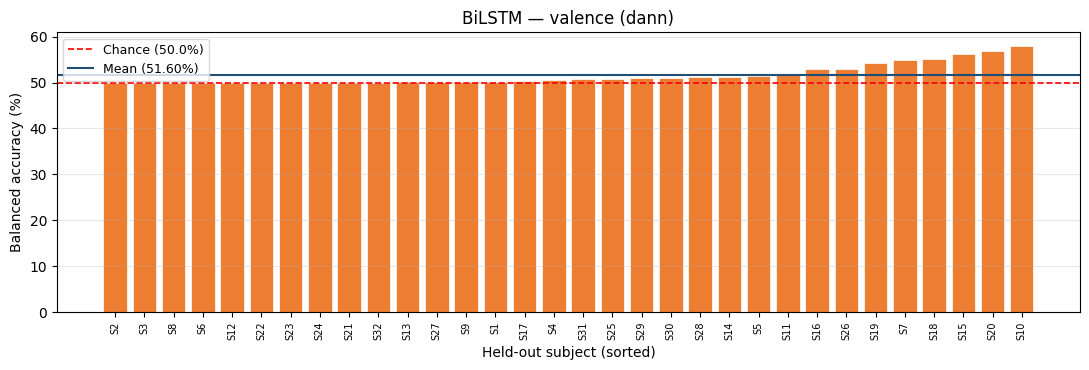

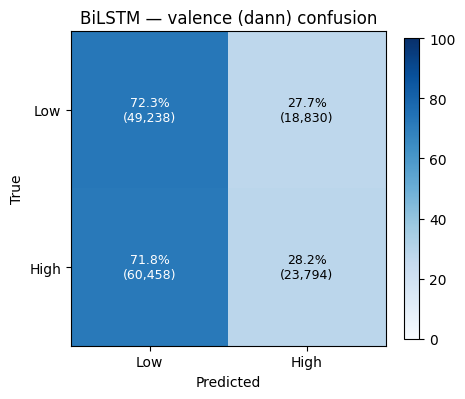

In [16]:
import matplotlib.pyplot as plt

def plot_per_subject(model_name, task, variant):
    df = per_fold_all[(model_name, task, variant)].sort_values('bal').reset_index(drop=True)
    chance = 100.0 / get_n_classes(task)
    mean_bal = df['bal'].mean()
    fig, ax = plt.subplots(figsize=(11, 3.8))
    colors = ['#c0392b' if v < chance else '#ED7D31' for v in df['bal']]
    ax.bar(range(len(df)), df['bal'], color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(chance, color='red', linestyle='--', linewidth=1.2, label=f'Chance ({chance:.1f}%)')
    ax.axhline(mean_bal, color='#1F4E79', linewidth=1.5, label=f'Mean ({mean_bal:.2f}%)')
    ax.set_xlabel('Held-out subject (sorted)'); ax.set_ylabel('Balanced accuracy (%)')
    ax.set_title(f'{model_name} — {task} ({variant})')
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels([f'S{int(s)}' for s in df['sid']], rotation=90, fontsize=7)
    ax.legend(loc='upper left', fontsize=9); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / f'per_subject_{model_name}_{task}_{variant}.png', dpi=140, bbox_inches='tight')
    plt.show()

def plot_confusion(model_name, task, variant):
    cm = cms_all[(model_name, task, variant)].astype(float)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    n = cm.shape[0]
    names = (['Low','High'] if task in ('valence','arousal') else ['Neg','Neu','Pos'])
    fig, ax = plt.subplots(figsize=(4.8, 4.1))
    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    for i in range(n):
        for j in range(n):
            c = 'white' if cm_pct[i,j] > 50 else 'black'
            ax.text(j, i, f'{cm_pct[i,j]:.1f}%\n({int(cm[i,j]):,})', ha='center', va='center', color=c, fontsize=9)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(names); ax.set_yticklabels(names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{model_name} — {task} ({variant}) confusion')
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / f'confusion_{model_name}_{task}_{variant}.png', dpi=140, bbox_inches='tight')
    plt.show()

plot_per_subject('BiLSTM', 'valence', 'dann')
plot_confusion('BiLSTM', 'valence', 'dann')

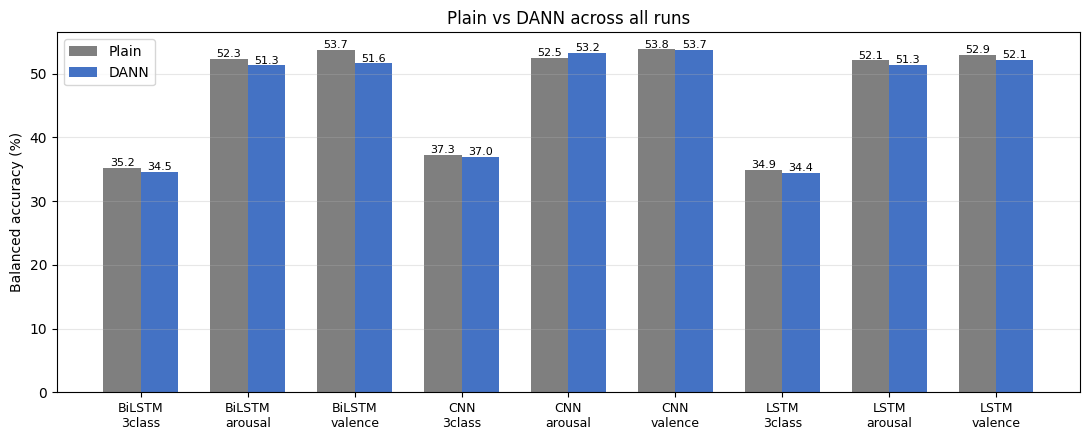

variant,model,task,dann,plain,delta
0,BiLSTM,3class,34.537331,35.223563,-0.686232
1,BiLSTM,arousal,51.293070,52.301783,-1.008714
2,BiLSTM,valence,51.601247,53.747173,-2.145926
3,CNN,3class,36.962666,37.289212,-0.326545
4,CNN,arousal,53.247923,52.491942,0.755981
5,CNN,valence,53.698974,53.801723,-0.102749
6,LSTM,3class,34.360870,34.920037,-0.559167
7,LSTM,arousal,51.343534,52.081635,-0.738101
8,LSTM,valence,52.097894,52.871004,-0.773110


In [17]:
comp = SUMMARY.pivot_table(index=['model','task'], columns='variant', values='bal_mean')
comp['delta'] = comp['dann'] - comp['plain']
comp = comp.reset_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(comp)); w = 0.35
ax.bar(x - w/2, comp['plain'], w, label='Plain', color='#7f7f7f')
ax.bar(x + w/2, comp['dann'],  w, label='DANN',  color='#4472C4')
for i, (p, d) in enumerate(zip(comp['plain'], comp['dann'])):
    ax.text(i - w/2, p + 0.3, f'{p:.1f}', ha='center', fontsize=8)
    ax.text(i + w/2, d + 0.3, f'{d:.1f}', ha='center', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f'{r.model}\n{r.task}' for r in comp.itertuples()], fontsize=9)
ax.set_ylabel('Balanced accuracy (%)')
ax.set_title('Plain vs DANN across all runs')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plain_vs_dann_comparison.png', dpi=140, bbox_inches='tight')
plt.show()
comp

## 10. Persistence
Per-fold CSVs and pooled confusion matrices for the Report 3 write-up.

In [18]:
for key, df in per_fold_all.items():
    tag = '_'.join(key)
    df.to_csv(RESULTS_DIR / f'per_fold_{tag}.csv', index=False)
for key, cm in cms_all.items():
    tag = '_'.join(key)
    np.save(RESULTS_DIR / f'cm_{tag}.npy', cm)

print('Saved to:', RESULTS_DIR)

Saved to: /content/drive/MyDrive/case_study_2/results/report3_deep
